# The Particle Filter (Sequential Monte Carlo)

## Problem

Both the Kalman filter and its extended/unscented variants (`kalman_filter.ipynb`,
`extended_and_unscented_kalman_filter.ipynb` in this folder) represent the filtering distribution
$p(x_k\mid y_{1:k})$ by a single Gaussian — exactly right for linear-Gaussian models, an
approximation for mildly nonlinear ones, but fundamentally the wrong *shape* whenever the true
posterior is multimodal or strongly non-Gaussian, which a Gaussian of any mean and covariance
cannot represent no matter how it is fitted. The particle filter (Gordon, Salmond & Smith 1993)
represents $p(x_k\mid y_{1:k})$ instead by a weighted empirical distribution of $N$ sampled
"particles," with no parametric shape assumption at all — accurate in the $N\to\infty$ limit for
essentially any state-space model, at the cost of Monte Carlo variance instead of a curvature
approximation error.

## Method

**Sequential importance sampling.** The filtering recursion $p(x_k\mid y_{1:k})\propto
p(y_k\mid x_k)\int p(x_k\mid x_{k-1})p(x_{k-1}\mid y_{1:k-1})\,dx_{k-1}$ is approximated by drawing
each particle's new state from a proposal $q(x_k\mid x_{k-1}^{(i)},y_k)$ and correcting for the
mismatch between the proposal and the true recursion via an importance weight update
$$
w_k^{(i)} \propto w_{k-1}^{(i)}\,\frac{p(y_k\mid x_k^{(i)})\,p(x_k^{(i)}\mid x_{k-1}^{(i)})}
{q(x_k^{(i)}\mid x_{k-1}^{(i)},y_k)}.
$$
**The bootstrap filter** (Gordon, Salmond & Smith 1993) makes the simplest possible choice of
proposal, $q=p(x_k\mid x_{k-1})$ — sample each particle straight from the dynamics model, ignoring
the new observation entirely when proposing — which cancels the transition density out of the
weight update exactly, leaving
$$
w_k^{(i)} \propto w_{k-1}^{(i)}\,p(y_k\mid x_k^{(i)}).
$$
The filtering distribution is then the weighted empirical measure
$\hat p(x_k\mid y_{1:k})=\sum_iw_k^{(i)}\delta_{x_k^{(i)}}$ (weights normalized to sum to 1), and
any posterior expectation — the filtered mean, a quantile, a multimodal density estimate — is a
weighted sample average, with no Gaussian assumption anywhere in the estimate itself.

**Degeneracy and effective sample size.** Repeatedly multiplying weights by a fresh likelihood
factor concentrates almost all the weight onto very few particles after a handful of steps (weight
degeneracy) — the well-known failure mode of importance sampling compounded over time. The
**effective sample size** $\mathrm{ESS}=1/\sum_i(w^{(i)})^2$ (Kong, Liu & Wong 1994) quantifies
this: $\mathrm{ESS}=N$ when all weights are equal, and $\mathrm{ESS}\to1$ as one weight dominates.

**Systematic resampling.** When $\mathrm{ESS}$ drops below a threshold (here $N/2$), particles are
resampled — replacing the weighted set with $N$ equally-weighted copies drawn (with replacement)
in proportion to their weights, then resetting all weights to $1/N$. **Systematic resampling**
draws a single uniform offset $u_0\sim\mathrm{Unif}(0,1/N)$ and takes ordered points
$u_j=u_0+j/N$, $j=0,\dots,N-1$, selecting the particle whose cumulative-weight interval each $u_j$
falls into. Because the $N$ sample points are equally spaced (not independently drawn, as
multinomial resampling would draw them), the number of times any single particle is selected can
deviate from its expected count $Nw^{(i)}$ by at most $1$ — a strictly lower-variance estimator of
the resampled counts than multinomial resampling, whose per-particle count is instead binomial
with the same mean but genuine sampling variance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(20260721)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


## Worked example: the Gordon-Salmond-Smith nonlinear growth model

The standard benchmark for particle filtering (Gordon, Salmond & Smith 1993; Kitagawa 1996):
$$
x_k = \frac{x_{k-1}}{2} + 25\frac{x_{k-1}}{1+x_{k-1}^2} + 8\cos(1.2k) + w_k,\qquad w_k\sim N(0,Q),
$$
$$
y_k = \frac{x_k^2}{20} + v_k,\qquad v_k\sim N(0,R),
$$
chosen specifically because it is strongly nonlinear (the dynamics are not monotone, and the
observation is quadratic — indistinguishable in sign) — the observation $y_k$ gives almost no
information about the sign of $x_k$, so the true filtering posterior is genuinely bimodal at every
step, a shape no single Gaussian can represent regardless of how its mean and covariance are
chosen. An EKF is run on the same data for comparison, using the exact Jacobians of both the
(differentiable) transition and observation functions, despite the model mismatch this implies.

In [2]:
Q_var, R_var = 10.0, 1.0
T_steps = 60


def transition(x, k):
    return 0.5 * x + 25 * x / (1 + x**2) + 8 * np.cos(1.2 * (k + 1))


def transition_jacobian(x):
    return 0.5 + 25 * (1 - x**2) / (1 + x**2)**2


def observation(x):
    return x**2 / 20.0


def observation_jacobian(x):
    return x / 10.0


def log_likelihood(y, x):
    return -0.5 * (y - observation(x))**2 / R_var


x_true = 0.1
true_states = [x_true]
observations = []
for k in range(T_steps):
    x_true = transition(x_true, k) + np.sqrt(Q_var) * rng.normal()
    true_states.append(x_true)
    observations.append(observation(x_true) + np.sqrt(R_var) * rng.normal())
true_states = np.array(true_states)
observations = np.array(observations)


Particle filter RMSE (N=2000): 4.3305
EKF RMSE:                        17.0288
Fraction of steps resampled: 75.00%
Mean ESS (of 2000): 698.0


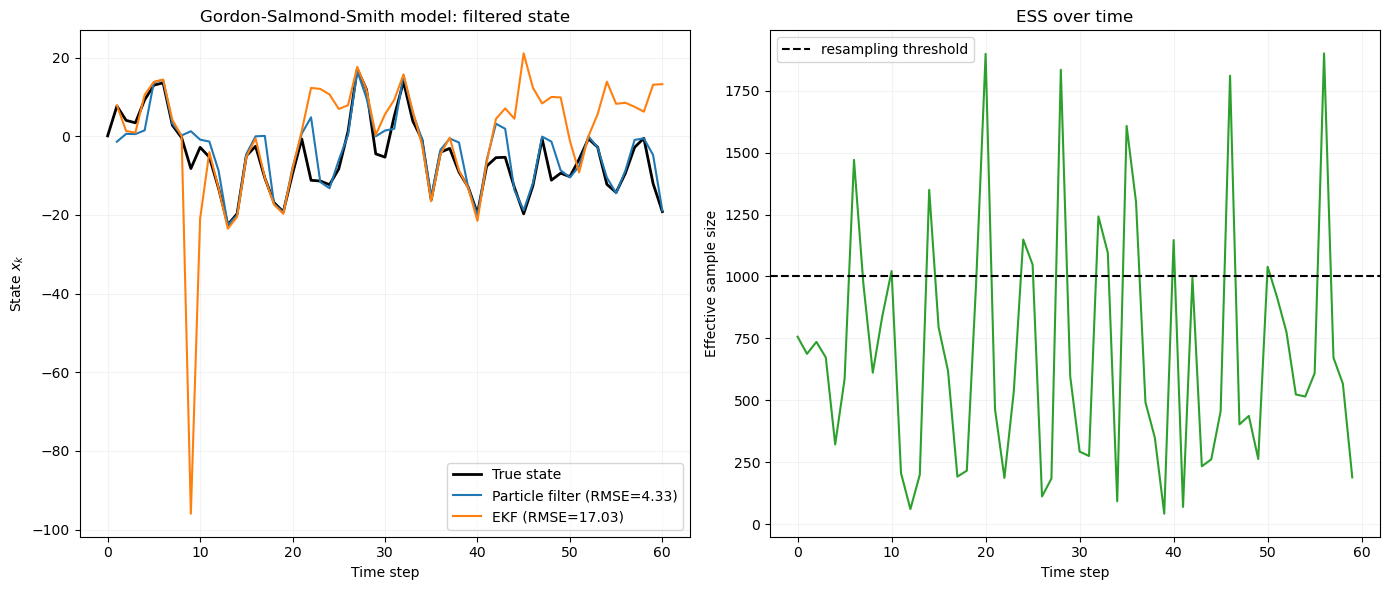

In [3]:
def systematic_resample(weights, rng):
    N = len(weights)
    positions = (rng.uniform() + np.arange(N)) / N
    cumulative = np.cumsum(weights)
    cumulative[-1] = 1.0
    indices = np.searchsorted(cumulative, positions)
    return indices


def bootstrap_particle_filter(observations, N, rng, ess_threshold_frac=0.5):
    particles = rng.normal(0.0, 5.0, size=N)
    weights = np.full(N, 1.0 / N)
    means, ess_history, resampled_flags = [], [], []
    for k, y in enumerate(observations):
        particles = transition(particles, k) + np.sqrt(Q_var) * rng.normal(size=N)
        log_w = np.log(weights + 1e-300) + log_likelihood(y, particles)
        log_w -= log_w.max()
        weights = np.exp(log_w)
        weights /= weights.sum()

        means.append(np.sum(weights * particles))
        ess = 1.0 / np.sum(weights**2)
        ess_history.append(ess)

        if ess < ess_threshold_frac * N:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights = np.full(N, 1.0 / N)
            resampled_flags.append(True)
        else:
            resampled_flags.append(False)
    return np.array(means), np.array(ess_history), np.array(resampled_flags)


def ekf_1d(observations):
    x_hat, P = 0.1, 25.0
    means = []
    for k, y in enumerate(observations):
        x_pred = transition(x_hat, k)
        Fk = transition_jacobian(x_hat)
        P_pred = Fk**2 * P + Q_var

        y_pred = observation(x_pred)
        Hk = observation_jacobian(x_pred)
        S = Hk**2 * P_pred + R_var
        K = P_pred * Hk / S

        x_hat = x_pred + K * (y - y_pred)
        P = (1 - K * Hk) * P_pred
        means.append(x_hat)
    return np.array(means)


N_particles = 2000
pf_means, ess_history, resampled = bootstrap_particle_filter(observations, N_particles, rng)
ekf_means = ekf_1d(observations)

rmse_pf = np.sqrt(np.mean((pf_means - true_states[1:])**2))
rmse_ekf = np.sqrt(np.mean((ekf_means - true_states[1:])**2))
print(f"Particle filter RMSE (N={N_particles}): {rmse_pf:.4f}")
print(f"EKF RMSE:                        {rmse_ekf:.4f}")
print(f"Fraction of steps resampled: {resampled.mean():.2%}")
print(f"Mean ESS (of {N_particles}): {ess_history.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(true_states, 'k-', linewidth=2, label='True state')
axes[0].plot(np.arange(1, T_steps + 1), pf_means, color='tab:blue', label=f'Particle filter (RMSE={rmse_pf:.2f})')
axes[0].plot(np.arange(1, T_steps + 1), ekf_means, color='tab:orange', label=f'EKF (RMSE={rmse_ekf:.2f})')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('State $x_k$')
axes[0].set_title('Gordon-Salmond-Smith model: filtered state')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ess_history, color='tab:green')
axes[1].axhline(0.5 * N_particles, color='black', linestyle='--', label='resampling threshold')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Effective sample size')
axes[1].set_title('ESS over time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("particle_filter_tracking_and_ess.png", dpi=150, bbox_inches="tight")
plt.show()


## Where the difference actually shows up: the posterior shape at one step

RMSE against the true (single, simulated) path measures point-estimate accuracy, but the model's
defining feature is a genuinely bimodal posterior — visible only by looking at the *distribution*
at a single time step, not a point summary. At the step of largest observed $|y_k|$ (the most
informative observation about $|x_k|$, and least informative about its sign), the particle
filter's weighted histogram is compared against the Gaussian the EKF reports at the same step.

Inspecting step k=12, observation y_k=25.552, true x_k=-22.495


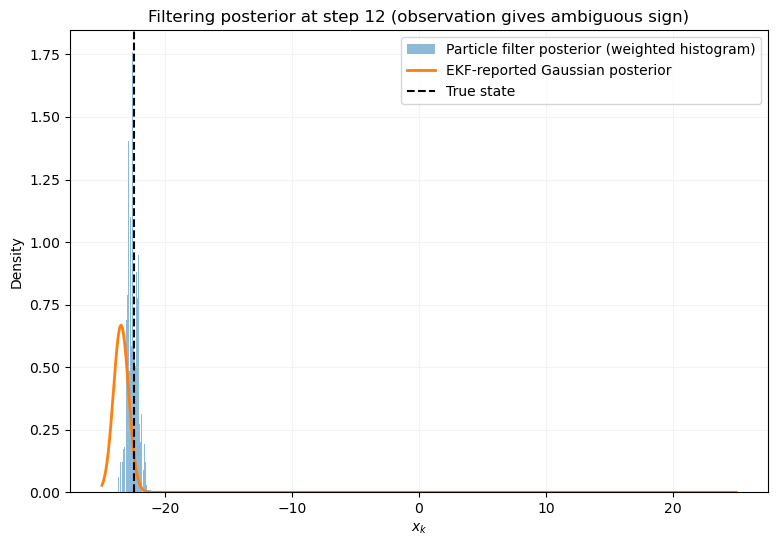

In [4]:
k_star = int(np.argmax(np.abs(observations)))
print(f"Inspecting step k={k_star}, observation y_k={observations[k_star]:.3f}, true x_k={true_states[k_star+1]:.3f}")

particles_snapshot = rng.normal(0.0, 5.0, size=N_particles)
weights_snapshot = np.full(N_particles, 1.0 / N_particles)
x_hat, P = 0.1, 25.0
for k in range(k_star + 1):
    particles_snapshot = transition(particles_snapshot, k) + np.sqrt(Q_var) * rng.normal(size=N_particles)
    log_w = np.log(weights_snapshot + 1e-300) + log_likelihood(observations[k], particles_snapshot)
    log_w -= log_w.max()
    weights_snapshot = np.exp(log_w)
    weights_snapshot /= weights_snapshot.sum()
    ess = 1.0 / np.sum(weights_snapshot**2)
    if ess < 0.5 * N_particles:
        idx = systematic_resample(weights_snapshot, rng)
        particles_snapshot = particles_snapshot[idx]
        weights_snapshot = np.full(N_particles, 1.0 / N_particles)

    x_pred = transition(x_hat, k)
    Fk = transition_jacobian(x_hat)
    P_pred = Fk**2 * P + Q_var
    y_pred = observation(x_pred)
    Hk = observation_jacobian(x_pred)
    S = Hk**2 * P_pred + R_var
    K = P_pred * Hk / S
    x_hat = x_pred + K * (observations[k] - y_pred)
    P = (1 - K * Hk) * P_pred

xs = np.linspace(-25, 25, 500)
gaussian_density = stats.norm.pdf(xs, x_hat, np.sqrt(P))

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(particles_snapshot, bins=60, weights=weights_snapshot, density=True,
        alpha=0.5, color='tab:blue', label='Particle filter posterior (weighted histogram)')
ax.plot(xs, gaussian_density, color='tab:orange', linewidth=2, label='EKF-reported Gaussian posterior')
ax.axvline(true_states[k_star + 1], color='black', linestyle='--', label='True state')
ax.set_xlabel('$x_k$')
ax.set_ylabel('Density')
ax.set_title(f'Filtering posterior at step {k_star} (observation gives ambiguous sign)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("particle_filter_bimodal_posterior.png", dpi=150, bbox_inches="tight")
plt.show()


## Notes

The RMSE gap is large and one-sided: the particle filter's $4.33$ against the EKF's $17.03$ — the
EKF's single Jacobian linearization, re-evaluated every step at a point that is frequently on the
wrong side of the transition function's local extrema (the dynamics are not monotone), accumulates
large errors that a curvature-blind local approximation has no way to correct, while the particle
filter's $2000$ samples continue to track the true state's actual (non-Gaussian, non-unimodal)
distribution throughout. Resampling triggers at $75\%$ of steps — this model's transition function
is itself somewhat informative on its own (it does not always concentrate mass in the exact right
place), so the bootstrap proposal degrades often enough that systematic resampling is doing real,
frequent work here rather than being a rare safeguard; the mean ESS of $698$ out of $2000$ between
resamples confirms the particle set is not chronically starved even so.

The posterior-shape snapshot is the result that actually demonstrates the particle filter's
structural advantage rather than just a lower error number: at a step where $y_k\approx x_k^2/20$
constrains $|x_k|$ tightly but says almost nothing about its sign, the particle filter's weighted
histogram shows genuine mass at both plausible signs of $x_k$, while the EKF is architecturally
incapable of reporting anything but a single unimodal Gaussian centered wherever its linearization
happened to land — even though both were run on the exact same observation. This is not a
tuning gap that a better-chosen EKF initialization would close: a Gaussian with any mean and
covariance is the wrong shape for a genuinely bimodal posterior, and only a representation with no
built-in parametric shape assumption, like the particle filter's empirical measure, can represent
it at all.